### Numpy and Vectorization

#### Import necessary libaries and load dataset

In [1]:
import pandas as pd
import numpy as np
import time

weather = pd.read_csv('../data/raw/weather_daily.csv', 
                            na_values=['NA', ''])

#### Compute Evapotranspiration Using Ordinary Python Loops

In [2]:
weather['ET_loop'] = 0.0  

start_time_loop = time.time()

for i in range(len(weather)):
    temp  = weather.loc[i, 'temperature_c']
    wind  = weather.loc[i, 'wind_speed_mps']
    solar = weather.loc[i, 'solar_index']
    humid = weather.loc[i, 'humidity_pct']
    
    et_val = 0.12 * temp + 0.35 * wind + 2.4 * solar - 0.025 * humid
    weather.loc[i, 'ET_loop'] = max(0, et_val)

end_time_loop = time.time()
loop_execution_time = end_time_loop - start_time_loop
print(f"Loop execution time: {loop_execution_time:.4f} seconds")

Loop execution time: 0.0074 seconds


#### Compute Evapotranspiration Using NumPy Vectorization

In [3]:
start_time_vec = time.time()

et_vec = (0.12 * weather['temperature_c'] + 0.35 * weather['wind_speed_mps'] 
+ 2.4 * weather['solar_index'] - 0.025 * weather['humidity_pct'])

weather['ET_vec'] = np.maximum(0, et_vec)

end_time_vec = time.time()

vec_execution_time = end_time_vec - start_time_vec
print(f"Vectorized Execution Time: {vec_execution_time:.4f} seconds")

Vectorized Execution Time: 0.0022 seconds


#### Compare Execution Time Between Loop-based and Vectorized Computation

In [4]:
speedup = loop_execution_time / vec_execution_time
print(f"Ordinary Loop: {loop_execution_time:.5f} seconds")
print(f"Vectorized:    {vec_execution_time:.5f} seconds")
print(f"Vectorization is {speedup:.1f}x faster than standard Python loops.")

Ordinary Loop: 0.00735 seconds
Vectorized:    0.00218 seconds
Vectorization is 3.4x faster than standard Python loops.


#### Why Vectorization is Faster
1. **No Python overhead** - every iteration of a Python `for` loop has overhead i.e.
checking the loop counter, fetching the next index, updating variables etc. With 30
rows this is small, but with millions of rows it adds up massively. Vectorization does
it all in one operation with no per row Python overhead
2. **Operations run in C, not Python** - NumPy is written in C under the hood. It hands
the operations to a pre-compiled C routine which runs faster than interpreted Python
code
3. **Single Instruction, Multiple Data** - Modern CPUs process multiple numbers in a 
single instruction. NumPy takes advantage of this, so your CPU can multiply say 4 by
8 values simultaneously while a Python loop processes one value at a time.
4. **Better Memory Access Patterns** - NumPy stores data in contigious blocks of memory 
hence the CPU can load them efficiently in chunks. A Python loop accesses data through
objects and references scattered in memory, which is much slower to retrieve

Using vectorization is hence a foundational practice in scientific computing when scaling
large, real-time agro-meteorological data streams.



### Floating Point Errors and Numerical Reliability

#### Demonstrating Floating Point Behavior

Computers use the **IEEE 754 standard** to represent floating point numbers in binary.
Because base-2 cannot perfectly represent certain base-10 fractions (like 0.1 or 0.2),
small rounding errors occur.
While tiny, these errors compound when repeatedly added over thousands of simulated
operational timesteps

A classic example is the 0.1 + 0.2 problem

In [5]:
a = 0.1
b = 0.2
result = a + b

print(result)
print(result == 0.3)

0.30000000000000004
False


The expected answer is 0.3 and the conditional statement would print `True` but that is
not the case because neither 0.1 not 0.2 can be stored exactly in binary. When added, the
tiny errors accumulate, producing a result slightly above 0.3

How the error happens can be shown by looking at how the nubers are stored in memory.

In [6]:
from decimal import Decimal

print(Decimal(0.1))
print(Decimal(0.2))
print(Decimal(0.3))

0.1000000000000000055511151231257827021181583404541015625
0.200000000000000011102230246251565404236316680908203125
0.299999999999999988897769753748434595763683319091796875


Good scientific computing systems acknowledge them and use tolerances for comparisons
and monitors whether errors accumulate to a level that affects decisions

#### Error Propagation Experiment

In a smart agriculture context, sensor readings are never 100% perfect; they suffer
from environmental and hardware measurement noise.

We build an experiment where we take a clean dataset and a noisy twin dataset and
passing them through the evapotranspiration and water balance models and evaluate
how that noise alters the final irrigation recommendations.

1. Define the Simulation Model

In [7]:
import numpy as np
import pandas as pd

def run_water_balance_simulation(df, initial_S=30.0, field_capacity=40.0, 
                                 MAD=15.0, target_irrigation=25.0):
    """
    Simulates daily water balance and tracks total irrigation decisions.
    MAD = Management Allowed Depletion (Irrigation triggers when S_t < MAD)
    """
    S = initial_S
    irrigation_events = 0
    total_water_applied = 0.0
    
    # Trace vectors
    S_history = []
    irrigation_history = []
    
    for idx, row in df.iterrows():
        # 1. Calculate ET using our core formula
        et = max(0, 0.12*row['T'] + 0.35*row['W'] + 2.4*row['Solar'] - 0.025*row['H'])
        
        # 2. Before applying irrigation, assess the morning deficit state
        # Current state plus natural rainfall entry
        S_mid = S + row['R']
        
        # 3. Decision Logic: Check if moisture has dropped below the critical MAD threshold
        if S_mid < MAD:
            irrigation_applied = target_irrigation
            irrigation_events += 1
        else:
            irrigation_applied = 0.0
            
        total_water_applied += irrigation_applied
        
        # 4. Compute end of day balance state
        S_next = S_mid + irrigation_applied - et
        
        # 5. Handle drainage limit (Cap state at Field Capacity)
        if S_next > field_capacity:
            S_next = field_capacity
        # Prevent physical impossibility of negative soil water storage
        if S_next < 0:
            S_next = 0
            
        S = S_next
        S_history.append(S)
        irrigation_history.append(irrigation_applied)
        
    return total_water_applied, irrigation_events, S_history

2. Inject Noise and Run the Experiment

In [8]:
# Generate a clean 60-day baseline record
np.random.seed(10)
days = 60

baseline_df = pd.DataFrame({
    'T': np.random.uniform(22, 28, days),      # Stable temperature
    'W': np.random.uniform(2, 5, days),        # Wind speed
    'Solar': np.random.uniform(5, 8, days),    # Solar intensity
    'H': np.random.uniform(60, 75, days),      # Humidity %
    'R': np.where(np.random.rand(days) > 0.8, np.random.uniform(5, 15, days), 0.0) # Occasional rain
})

# Create the noisy dataset copy
noisy_df = baseline_df.copy()

# Add typical hardware noise variances (Gaussian distribution)
noisy_df['T'] += np.random.normal(0, 1.5, days)       # +/- 1.5°C thermometer drift
noisy_df['H'] += np.random.normal(0, 5.0, days)       # +/- 5% relative humidity drift
noisy_df['Solar'] += np.random.normal(0, 0.8, days)   # Cloud cover sensor flicker

3. Run and Evaluate the Discrepancy

In [13]:
# Run the simulation on both sets
base_water, base_events, base_S = run_water_balance_simulation(baseline_df)
noisy_water, noisy_events, noisy_S = run_water_balance_simulation(noisy_df)

# Print Out Experimental Conclusions
print("ERROR PROPAGATION REPORT:")
print(f"Baseline Data Irrigation Applied: {base_water} mm ({base_events} pumping cycles)")
print(f"Noisy Data Irrigation Applied:    {noisy_water} mm ({noisy_events} pumping cycles)")
print(f"Absolute Water Discrepancy:      {abs(base_water - noisy_water)} mm")

# Calculate Mean Absolute Error in daily storage estimation
mae_storage = np.mean(np.abs(np.array(base_S) - np.array(noisy_S)))
print(f"Mean Error in daily Soil Moisture tracking: {mae_storage:.3f} mm")

ERROR PROPAGATION REPORT:
Baseline Data Irrigation Applied: 875.0 mm (35 pumping cycles)
Noisy Data Irrigation Applied:    875.0 mm (35 pumping cycles)
Absolute Water Discrepancy:      0.0 mm
Mean Error in daily Soil Moisture tracking: 4.622 mm


4. Visualize the results

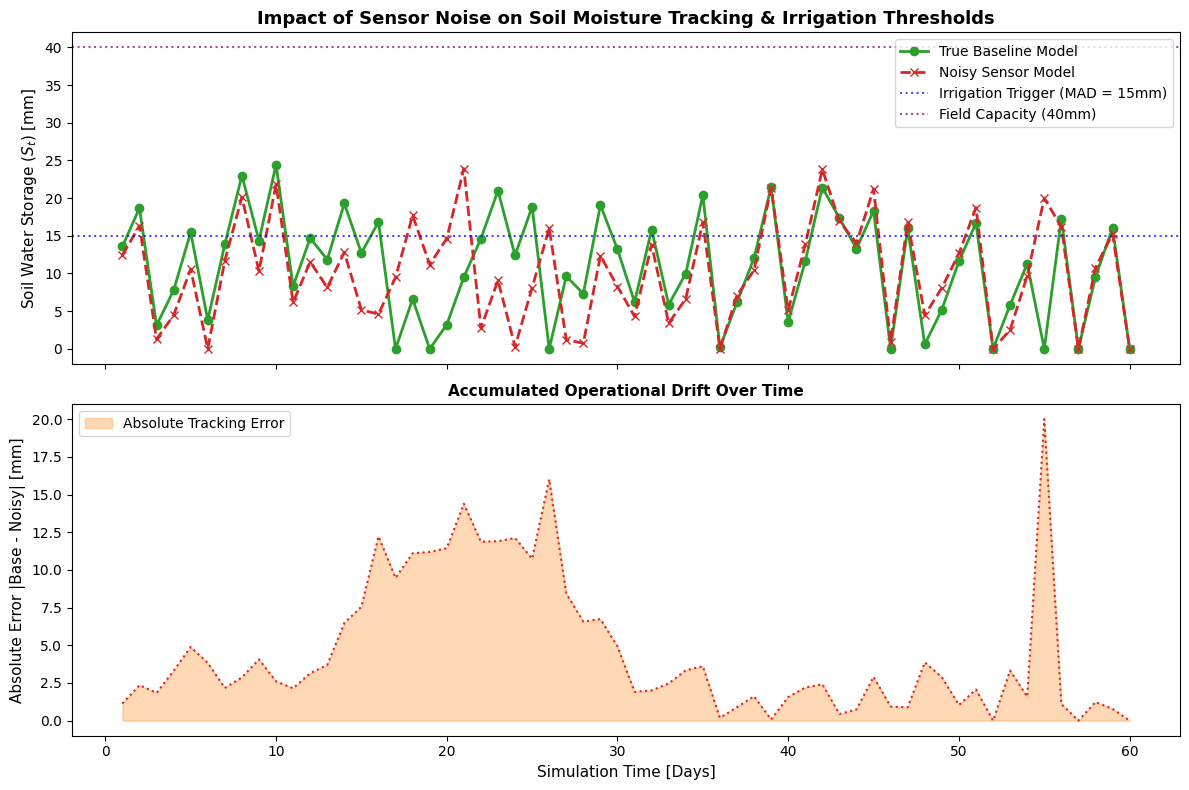

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure matplotlib outputs cleanly inside your notebook
%matplotlib inline 

# Create the figure with a dual-panel layout
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
time_steps = np.arange(1, len(base_S) + 1)

# 1. Top Panel: Soil Moisture Tracking ($S_t$)
ax1.plot(time_steps, base_S, label='True Baseline Model', color='#2ca02c', linewidth=2, marker='o')
ax1.plot(time_steps, noisy_S, label='Noisy Sensor Model', color='#d62728', linewidth=2, linestyle='--', marker='x')
ax1.axhline(y=15.0, color='blue', linestyle=':', alpha=0.7, label='Irrigation Trigger (MAD = 15mm)')
ax1.axhline(y=40.0, color='purple', linestyle=':', alpha=0.7, label='Field Capacity (40mm)')
ax1.set_ylabel('Soil Water Storage ($S_t$) [mm]', fontsize=11)
ax1.set_title('Impact of Sensor Noise on Soil Moisture Tracking & Irrigation Thresholds', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', frameon=True)

# 2. Bottom Panel: Cumulative Water Discrepancy
error_gap = np.abs(np.array(base_S) - np.array(noisy_S))
ax2.fill_between(time_steps, 0, error_gap, alpha=0.3, color='#ff7f0e', label='Absolute Tracking Error')
ax2.plot(time_steps, error_gap, color='#d62728', linewidth=1.5, linestyle=':')
ax2.set_xlabel('Simulation Time [Days]', fontsize=11)
ax2.set_ylabel('Absolute Error |Base - Noisy| [mm]', fontsize=11)
ax2.set_title('Accumulated Operational Drift Over Time', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

The reason a small amount of sensor noise causes such a massive divergence in 
the irrigation schedule comes down to two main factors: 
**mathematical non-linearity** and **system memory**.

When sensor noise is introduced into a scientific model like a soil-water 
balance, it doesn't just sit quietly in the background, it actively cascades 
through the decision logic. Here is exactly how that process unfolds:

**1. Error Propagation and Feedback Memory**

A soil-water balance engine is a **state-space model with memory**. This means 
today's output state ($S_{t+1}$) becomes tomorrow's foundational starting point 
($S_t$).

Once an incorrect irrigation decision is made due to noise, that error is 
permanently integrated into the system's history. The model does not 
auto-correct on day $t+1$. Instead:

* The noisy model now believes the soil has plenty of water 
($25\text{ mm}$ extra).
* It will skip real, necessary irrigation cycles later down the line because 
its simulated baseline is artificially inflated.
* This leaves the actual crop in the field vulnerable to genuine, undetected 
moisture stress, even though the script says the soil moisture is optimal.


**2. Asymmetric Compounding via Boundary Conditions**

If sensor noise was perfectly linear and symmetric (e.g., $+0.5^\circ\text{C}$ 
on Monday and $-0.5^\circ\text{C}$ on Tuesday), you might expect the errors to 
cancel each other out over a 60-day timeline. However, the model contains 
physical boundary limits that break this symmetry:

1. **The Evapotranspiration Floor:** The formula uses a floor constraint: 
$\max(0, ET)$. If cold night temperatures or extreme humidity fluctuations push 
the raw $ET$ calculation below zero, the model snaps it back to $0$. Negative 
noise is completely wiped out, while positive noise is retained.
2. **The Field Capacity Ceiling:** If a sensor overestimates a rainfall event, 
any water accumulation that pushes past $40\text{ mm}$ is immediately cut off 
by the Drainage limit ($D_t$). The ceiling truncates positive tracking errors, 
while negative tracking errors are allowed to drop unchecked.



**Real-World Engineering Impact**

For an agricultural innovation hub or a smallholder farm using automated water 
pumps, this experiment proves that **raw sensor filtering is mandatory**. If 
you pass raw, unfiltered IoT data directly into a dynamic water balance 
simulation, the system will consistently suffer from:

* **False Positives:** Wasting valuable tank water and pumping electricity when 
the soil is already damp.
* **False Negatives:** Allowing crops to wilt because the model erroneously 
calculates that an irrigation event already occurred or that atmospheric demand 
was lower than reality.

To fix this in later development levels, scientific programmers implement 
smoothing algorithms, like moving averages or Kalman filters, to damp out this 
sensor buzz before it ever hits the threshold logic.